<a href="https://colab.research.google.com/github/Harsh-bot-1603/Fashion_MNIST-Prediction/blob/main/Computer_Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision

## Computer vision libraries

1. `torchvision`
2. `torchvision.datasets`
3. `torchvision.models`
4. `torchvision.transforms`
5. `torch.utils.data.Dataset`
6. `torch.utils.data.DataLoader`

In [1]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt


## Getting a dataset

In [2]:
# Setup training data
train_data = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None
)

In [3]:
len(train_data),len(test_data)

(60000, 10000)

In [4]:
# See the first training example
image,label = train_data[0]
print(image," ",label)

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863, 0.0000, 0.0000, 0.0039, 0.0157, 0.0000,

In [5]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [6]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

### Visualize data

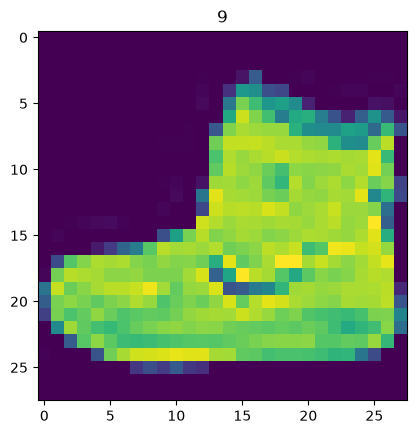

In [7]:
plt.imshow(image.squeeze())
plt.title(label)
plt.show()

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

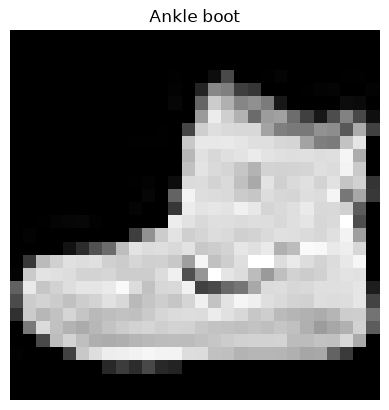

In [8]:
plt.imshow(image.squeeze(),cmap="gray")
plt.title(class_names[label])
plt.axis(False)

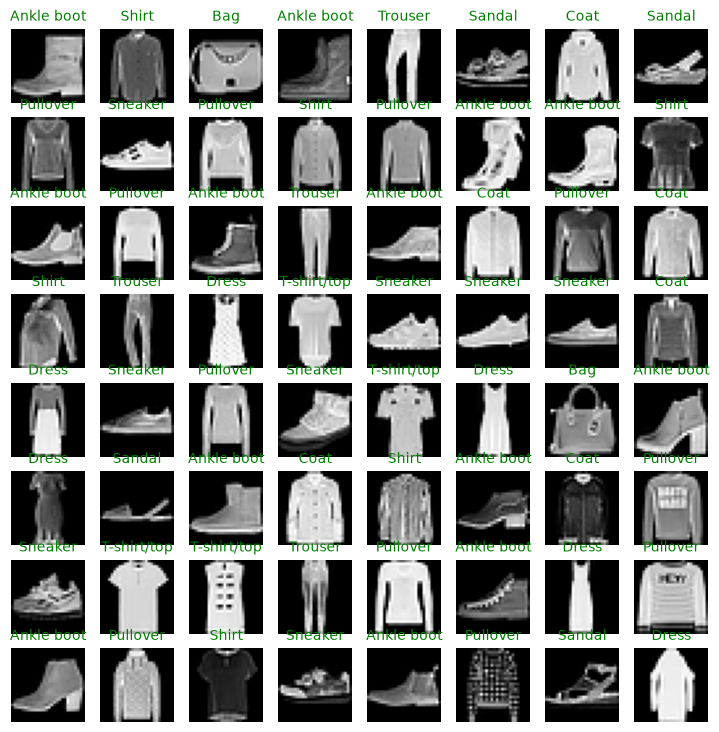

In [9]:
from numpy import size
# Plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows,cols=8,8
for i in range(1,rows*cols+1):
  random_idx = torch.randint(0,len(train_data),size=[1]).item()
  img,label = train_data[random_idx]
  fig.add_subplot(rows,cols,i)
  plt.imshow(img.squeeze(),cmap="gray")
  plt.title(class_names[label],c="green",size=10)
  plt.axis(False)

In [10]:
train_data,test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

## Prepare DataLoader

In [11]:
from torch.utils.data import DataLoader
# Setup the batch size hypreparameter
BATCH_SIZE = 32
# Turn dataset into iterables (batches)
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=True)
train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7fa535c46270>,
 <torch.utils.data.dataloader.DataLoader at 0x7fa534609450>)

In [12]:
print(f"DataLoaders : {train_dataloader,test_dataloader}")
print(f"Length of train_dataloader : {len(train_dataloader)}")
print(f"Length of test dataloader : {len(test_dataloader)}")

DataLoaders : (<torch.utils.data.dataloader.DataLoader object at 0x7fa535c46270>, <torch.utils.data.dataloader.DataLoader object at 0x7fa534609450>)
Length of train_dataloader : 1875
Length of test dataloader : 313


In [13]:
# Check what's inside the training dataloader
train_features_batch,train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape,train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size:torch.Size([1, 28, 28])
Label: 3, label size: torch.Size([])


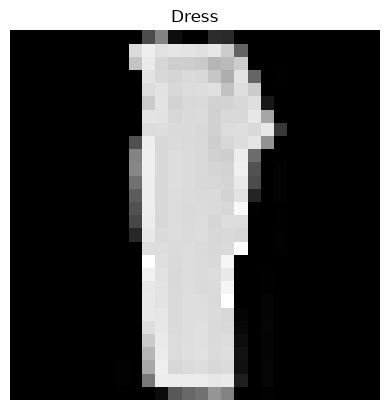

In [14]:
# Show a sample
torch.manual_seed(42)
random_idx = torch.randint(0,len(train_features_batch),size=[1]).item()
img,label = train_features_batch[random_idx],train_labels_batch[random_idx]

plt.imshow(img.squeeze(),cmap="gray")
plt.title(class_names[label])
plt.axis(False)
print(f"Image size:{img.shape}")
print(f"Label: {label}, label size: {label.shape}")

## Build a baseline model

In [15]:
# Creating a flatten layer
flatten_model = nn.Flatten()
#Get a single sample
x = train_features_batch[0]

# Flatten the sample
output = flatten_model(x)

print(f"Shape before flattening: {x.shape}")
print(f"Shape after flattenting: {output.shape}")


Shape before flattening: torch.Size([1, 28, 28])
Shape after flattenting: torch.Size([1, 784])


In [16]:
output.squeeze()

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000,
        0.0000, 0.0000, 0.0000, 0.3882, 0.2902, 0.2235, 0.1961, 0.1882, 0.0000,
        0.0000, 0.0039, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0118, 0.0000,
        0.0000, 0.0000, 0.0196, 0.8902, 0.8863, 0.8078, 0.8235, 0.8275, 0.8824,
        0.7608, 0.0000, 0.0000, 0.0000, 0.0000, 0.0078, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000,
        0.0000, 0.0392, 0.4000, 0.7725, 0.7843, 0.5176, 0.5451, 0.5176, 0.5686,
        0.5765, 0.7569, 0.9216, 0.2078, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000,
        0.1059, 0.7137, 0.8275, 0.8196, 0.7961, 0.7137, 0.6078, 0.6471, 0.6431,
        0.5843, 0.6510, 0.6941, 0.8157, 0.8392, 0.7882, 0.6235, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 

In [17]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
  def __init__(self,
              input_shape:int,
              hidden_units:int,
              output_shape:int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,out_features=hidden_units),
        nn.Linear(in_features=hidden_units,
                  out_features=output_shape)
    )
  def forward(self,x):
    return self.layer_stack(x)

In [18]:
torch.manual_seed(42)
model_0 = FashionMNISTModelV0(input_shape=28*28,
                              hidden_units=10,
                              output_shape=len(class_names)
                              ).to("cpu")
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [19]:
dummy_x = torch.rand([1,1,28,28])
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

In [20]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

### Setup loss and optimizer

In [21]:
def accuracy_fn(y_true,y_pred):
  correct = torch.eq(y_pred,y_true).sum().item()
  acc = (correct/len(y_pred))*100
  return acc

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.1)

### Creating a function to time our experiment

In [22]:
from timeit import default_timer as timer
def print_train_time(start: float,
                     end: float,
                     device: torch.device=None):
  total_time = end-start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

In [23]:
start_time = timer()
end_time = timer()
print_train_time(start=start_time,end=end_time,device="cpu")

Train time on cpu: 0.000 seconds


6.0474000008525763e-05

### Creating a training loop and training a model on batches of data

In [24]:
from tqdm.auto import tqdm

torch.manual_seed(42)
train_time_start_on_cpu = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch : {epoch}\n===========")

  ### Training

  train_loss = 0
  train_acc = 0 # Initialize train_acc

  # Add a loop to loop through the training batches
  for batch,(X,y) in enumerate(train_dataloader):
    model_0.train()
    y_pred = model_0(X)
    loss = loss_fn(y_pred,y)
    train_loss += loss # accumulate train loss
    train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1)) # accumulate train accuracy
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch % 400 == 0:
      print(f"Looked at : {batch*len(X)}/{len(train_dataloader.dataset)} sample.")

  # Divide total train loss and accuracy by length of train dataloader
  train_loss /= len(train_dataloader)
  train_acc /= len(train_dataloader)

  ### Testing
  test_loss,test_acc = 0,0
  model_0.eval()
  with torch.inference_mode():
    for X_test,y_test in test_dataloader:
      test_pred = model_0(X_test)
      test_loss += loss_fn(test_pred,y_test)
      test_acc += accuracy_fn(y_true=y_test,y_pred=test_pred.argmax(dim=1))

    # Divide total test loss and accuracy by length of test dataloader
    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

  print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss: .4f} | Test Acc : {test_acc: .2f}%")

# Calculate the training time

train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(train_time_start_on_cpu,train_time_end_on_cpu, str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch : 0
Looked at : 0/60000 sample.
Looked at : 12800/60000 sample.
Looked at : 25600/60000 sample.
Looked at : 38400/60000 sample.
Looked at : 51200/60000 sample.

Train Loss: 0.5904 | Train Acc: 79.17% | Test Loss:  0.5102 | Test Acc :  82.04%
Epoch : 1
Looked at : 0/60000 sample.
Looked at : 12800/60000 sample.
Looked at : 25600/60000 sample.
Looked at : 38400/60000 sample.
Looked at : 51200/60000 sample.

Train Loss: 0.4743 | Train Acc: 83.30% | Test Loss:  0.5268 | Test Acc :  81.68%
Epoch : 2
Looked at : 0/60000 sample.
Looked at : 12800/60000 sample.
Looked at : 25600/60000 sample.
Looked at : 38400/60000 sample.
Looked at : 51200/60000 sample.

Train Loss: 0.4537 | Train Acc: 84.19% | Test Loss:  0.5126 | Test Acc :  83.00%
Train time on cpu: 28.242 seconds


## Make predictions and get model_0 results

In [25]:
torch.manual_seed(42)
def eval_model(model:torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
  loss, acc = 0,0
  model.eval()
  with torch.inference_mode():
    for X,y in tqdm(data_loader):
      y_pred = model(X)

      loss += loss_fn(y_pred,y)
      acc += accuracy_fn(y_true=y,
                         y_pred=y_pred.argmax(dim=1))

    loss /= len(data_loader)
    acc /= len(data_loader)

    return {"model_name":model.__class__.__name__,
            "model_loss":loss.item(),
            "model_acc":acc}
model_0_results = eval_model(model_0,test_dataloader,loss_fn,accuracy_fn)

model_0_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.512529730796814,
 'model_acc': 83.00718849840256}

## Setup device agnostic code

In [26]:
torch.cuda.is_available()

True

In [27]:
# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [28]:
class FashionMNISTModelV1(nn.Module):
  def __init__(self,
               input_shape,
               hidden_units,
               output_shape):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,
                  out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,
                  out_features=output_shape),
        nn.ReLU()

    )

  def forward(self,x):
    return self.layer_stack(x)


In [29]:
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(28*28,
                              10,
                              len(class_names)).to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

### Setup loss,optimizer and evaluation metrics

In [30]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)
def accuracy_fn(y_true,y_pred):
  correct = torch.eq(y_true,y_pred).sum().item()
  acc = (correct/len(y_pred))*100
  return acc

### Functionizing training and testing loop

In [31]:
def train_step(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               optimizer:torch.optim.Optimizer,
               loss_fn:torch.nn.Module,
               accuracy_fn,
               device:torch.device=device):


  ### Training

  train_loss = 0
  train_acc = 0 # Initialize train_acc

  model.train()

  # Add a loop to loop through the training batches
  for batch,(X,y) in enumerate(data_loader):
    X,y = X.to(device),y.to(device)
    y_pred = model(X)
    loss = loss_fn(y_pred,y)
    train_loss += loss # accumulate train loss
    train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1)) # accumulate train accuracy
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  # Divide total train loss and accuracy by length of train dataloader
  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"Train loss: {train_loss:.5f} | Train acc: {train_acc:.4f}%")

In [32]:
def test_step(model:torch.nn.Module,
              data_loader:torch.utils.data.DataLoader,
              loss_fn:torch.nn.Module,
              accuracy_fn,
              device:torch.device=device):

  ### Testing
  test_loss,test_acc = 0,0
  model.eval()

  with torch.inference_mode():
    for X_test,y_test in data_loader:
      X_test,y_test = X_test.to(device),y_test.to(device)
      test_pred = model(X_test)
      test_loss += loss_fn(test_pred,y_test)
      test_acc += accuracy_fn(y_true=y_test,y_pred=test_pred.argmax(dim=1))

    # Divide total test loss and accuracy by length of test dataloader
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)

  print(f"\nTest Loss: {test_loss: .5f} | Test Acc : {test_acc: .2f}%")

In [33]:
torch.manual_seed(42)
from timeit import default_timer as timer
train_time_start_on_gpu = timer()

epochs = 3
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n=========")
  train_step(model=model_1,
             data_loader=train_dataloader,
             optimizer=optimizer,
             loss_fn=loss_fn,
             accuracy_fn=accuracy_fn,
             device=device
             )

  test_step(model=model_1,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)
  train_time_end_on_gpu = timer()
  total_train_time_model_1 = print_train_time(train_time_start_on_gpu,train_time_end_on_gpu,device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
Train loss: 1.09199 | Train acc: 61.3433%

Test Loss:  0.95690 | Test Acc :  64.98%
Train time on cuda: 10.281 seconds
Epoch: 1
Train loss: 0.73779 | Train acc: 73.6933%

Test Loss:  0.72388 | Test Acc :  74.21%
Train time on cuda: 20.920 seconds
Epoch: 2
Train loss: 0.66776 | Train acc: 76.0767%

Test Loss:  0.68751 | Test Acc :  75.64%
Train time on cuda: 31.489 seconds


In [34]:
torch.manual_seed(42)
def eval_model(model:torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device:torch.device=device):
  loss, acc = 0,0
  model.eval()
  with torch.inference_mode():
    for X,y in tqdm(data_loader):
      X,y = X.to(device),y.to(device)
      y_pred = model(X)

      loss += loss_fn(y_pred,y)
      acc += accuracy_fn(y_true=y,
                         y_pred=y_pred.argmax(dim=1))

    loss /= len(data_loader)
    acc /= len(data_loader)

    return {"model_name":model.__class__.__name__,
            "model_loss":loss.item(),
            "model_acc":acc}

In [35]:
# get model_1 results dictionary
model_1_results = eval_model(model_1,
                             test_dataloader,
                             loss_fn,
                             accuracy_fn,
                             device)
model_1_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.6881523728370667,
 'model_acc': 75.61900958466454}

In [36]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.512529730796814,
 'model_acc': 83.00718849840256}

## Model 2: Building a Convolution Neural Network

In [37]:
# Create a CNN

class FashionMNISTModelV2(nn.Module):
  def __init__(self,input_shape,hidden_units,output_shape):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)

    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7,
                  out_features=output_shape)
    )
  def forward(self,x):
    x = self.conv_block_1(x)
    #print(x.shape)
    x = self.conv_block_2(x)
    #print(x.shape)
    x = self.classifier(x)
    return x

In [38]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1,
                              hidden_units=10,
                              output_shape=len(class_names)).to(device)
model_2

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [39]:
# Setup loss function, optimizer,evaluation metrics
def accuracy_fn(y_true,y_pred):
  correct = torch.eq(y_true,y_pred).sum().item()
  acc = (correct/len(y_pred))*100
  return acc

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),lr=0.1)

### Training and testing

In [40]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

from timeit import default_timer as timer
train_time_start_mode_2 = timer()

epochs = 10
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n========")
  train_step(model=model_2,
             data_loader=train_dataloader,
             optimizer=optimizer,
             loss_fn=loss_fn,
             accuracy_fn=accuracy_fn,
             device=device)
  test_step(model=model_2,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)
train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(train_time_start_mode_2,train_time_end_model_2,device)


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0
Train loss: 0.59452 | Train acc: 78.4933%

Test Loss:  0.39090 | Test Acc :  85.99%
Epoch: 1
Train loss: 0.35981 | Train acc: 86.9667%

Test Loss:  0.39600 | Test Acc :  86.01%
Epoch: 2
Train loss: 0.32464 | Train acc: 88.2800%

Test Loss:  0.33293 | Test Acc :  87.70%
Epoch: 3
Train loss: 0.30270 | Train acc: 89.0083%

Test Loss:  0.31270 | Test Acc :  88.79%
Epoch: 4
Train loss: 0.28848 | Train acc: 89.6067%

Test Loss:  0.30695 | Test Acc :  88.86%
Epoch: 5
Train loss: 0.27881 | Train acc: 89.9467%

Test Loss:  0.31584 | Test Acc :  88.91%
Epoch: 6
Train loss: 0.27068 | Train acc: 90.1817%

Test Loss:  0.31252 | Test Acc :  89.29%
Epoch: 7
Train loss: 0.26431 | Train acc: 90.3417%

Test Loss:  0.30240 | Test Acc :  88.85%
Epoch: 8
Train loss: 0.26098 | Train acc: 90.4933%

Test Loss:  0.29398 | Test Acc :  89.31%
Epoch: 9
Train loss: 0.25272 | Train acc: 90.8383%

Test Loss:  0.28752 | Test Acc :  89.49%
Train time on cuda: 124.448 seconds


In [41]:
model_2_results = eval_model(model=model_2,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn,
                             device=device)
model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.2868475914001465,
 'model_acc': 89.5067891373802}

In [42]:
import pandas as pd
compare_results = pd.DataFrame([model_0_results,model_1_results,model_2_results])
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.512530,83.007188
1,FashionMNISTModelV1,0.688152,75.619010
2,FashionMNISTModelV2,0.286848,89.506789


In [43]:
# Add training time to result comparision
compare_results["training_time"] = [total_train_time_model_0,
                                    total_train_time_model_1,
                                    total_train_time_model_2]
compare_results

,model_name,model_loss,model_acc,training_time
0,FashionMNISTModelV0,0.512530,83.007188,28.241532
1,FashionMNISTModelV1,0.688152,75.619010,31.489492
2,FashionMNISTModelV2,0.286848,89.506789,124.448203


Text(0.5, 0, 'moodel')

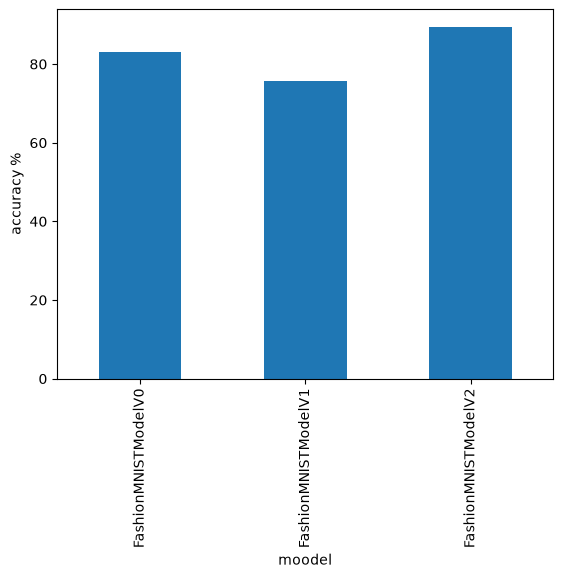

In [44]:
# Visualize our training results
compare_results.set_index("model_name")["model_acc"].plot(kind="bar")
plt.ylabel("accuracy %")
plt.xlabel("moodel")

## Make and evaluate random predictions with best model

In [45]:
def make_predictions(model:torch.nn.Module,
                     data:list,
                     device:torch.device=device):
  pred_probs = []
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for sample in data:
      sample = torch.unsqueeze(sample,dim=0).to(device)
      pred_logit = model(sample)
      pred_prob = torch.softmax(pred_logit.squeeze(),dim=0)
      pred_probs.append(pred_prob.cpu())

  return torch.stack(pred_probs)

In [46]:
import random
# random.seed(42)
test_samples = []
test_labels = []
for sample,label in random.sample(list(test_data),k=9):
  test_samples.append(sample)
  test_labels.append(label)

test_samples[0].shape

torch.Size([1, 28, 28])

Text(0.5, 1.0, 'T-shirt/top')

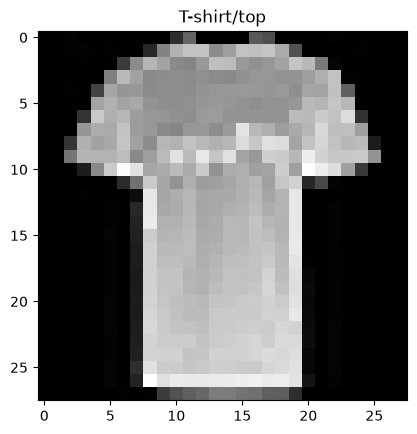

In [47]:
plt.imshow(test_samples[0].squeeze(),cmap="gray")
plt.title(class_names[test_labels[0]])

In [48]:
pred_probs = make_predictions(model=model_2,
                              data=test_samples)
pred_probs[:2]

tensor([[9.9750e-01, 3.2299e-06, 2.0361e-04, 1.2025e-04, 2.8861e-06, 5.8825e-09,
         2.1694e-03, 3.7751e-08, 3.1933e-06, 4.6594e-09],
        [1.5635e-04, 6.2537e-06, 3.1991e-02, 1.8146e-06, 9.5540e-01, 3.7375e-05,
         1.2199e-02, 9.9245e-09, 1.0196e-04, 1.0951e-04]])

In [49]:
# Convert probabilities to labels

pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([0, 4, 0, 2, 7, 0, 8, 8, 6])

In [50]:
test_labels,pred_classes

([0, 4, 0, 2, 7, 0, 6, 8, 2], tensor([0, 4, 0, 2, 7, 0, 8, 8, 6]))

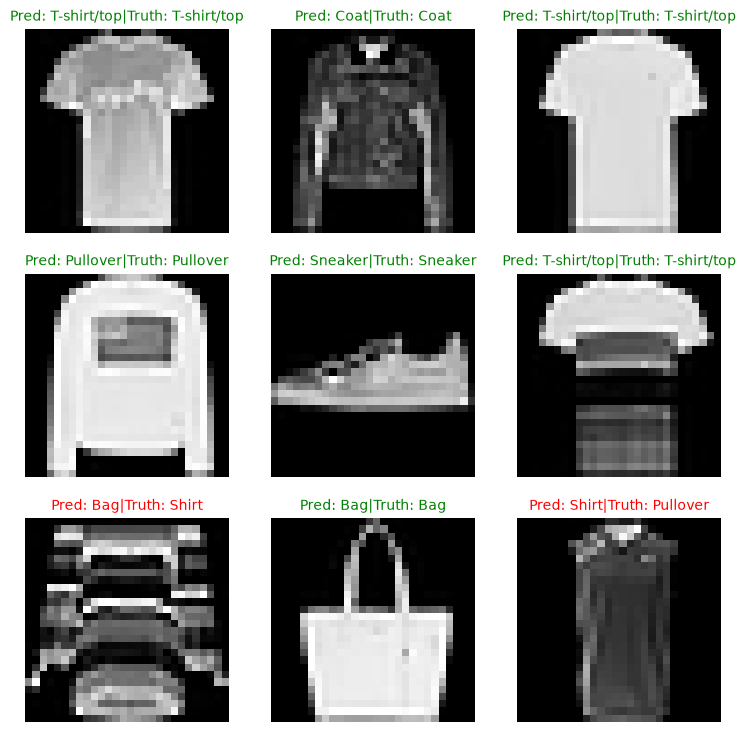

In [51]:
plt.figure(figsize=(9,9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  plt.subplot(nrows,ncols,i+1)
  plt.imshow(sample.squeeze(),cmap="gray")
  pred_label = class_names[pred_classes[i]]
  truth_label = class_names[test_labels[i]]
  title_text = f"Pred: {pred_label}|Truth: {truth_label}"

  if pred_label == truth_label:
    plt.title(title_text,fontsize=10,c="g")
  else:
    plt.title(title_text,fontsize=10,c="r")
  plt.axis(False)

## Making a confusion matrix for further prediction evaluation

In [52]:
# Make predictions with trained model
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X,y in tqdm(test_dataloader,desc='Making predictions...'):
    X,y = X.to(device),y.to(device)
    y_logit = model_2(X)
    y_pred = torch.softmax(y_logit.squeeze(),dim=0).argmax(dim=1)
    y_preds.append(y_pred.cpu())

#print(y_preds)
y_pred_tensor = torch.cat(y_preds)
y_pred_tensor

Making predictions...:   0%|          | 0/313 [00:00<?, ?it/s]

tensor([8, 5, 2,  ..., 5, 4, 2])

In [53]:
len(y_pred_tensor)

10000

In [54]:
try:
  import torchmetrics,mlxtend
  print(f"mlxtend version: {mlxtend.__version__}")
  assert int(mlxtend.__version__.split(".")[1])>=19,"mlxtend version should be 0.19.0 or higher"
except:
  !pip install torchmetrics -U mlxtend
  import torchmetrics,mlxtend
  print(f"mlxtend version:{mlxtend.__version__}")

mlxtend version: 0.25.0


In [55]:
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

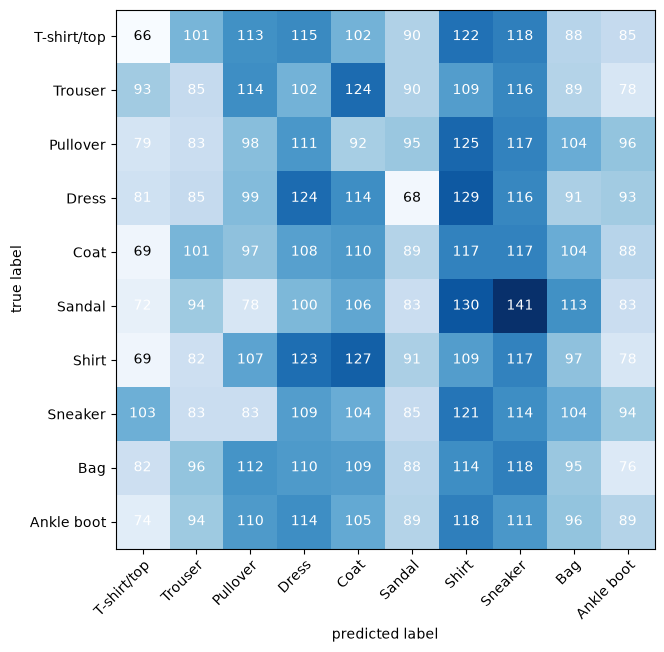

In [56]:
import mlxtend
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# Steup confusion instance and compare predictions to targets
confmat = ConfusionMatrix(task='multiclass', num_classes=len(class_names))
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)
# plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), # matplotlib likes working with numpy
    class_names=class_names,
    figsize=(10,7)

  )

In [57]:
confmat_tensor

tensor([[ 66, 101, 113, 115, 102,  90, 122, 118,  88,  85],
        [ 93,  85, 114, 102, 124,  90, 109, 116,  89,  78],
        [ 79,  83,  98, 111,  92,  95, 125, 117, 104,  96],
        [ 81,  85,  99, 124, 114,  68, 129, 116,  91,  93],
        [ 69, 101,  97, 108, 110,  89, 117, 117, 104,  88],
        [ 72,  94,  78, 100, 106,  83, 130, 141, 113,  83],
        [ 69,  82, 107, 123, 127,  91, 109, 117,  97,  78],
        [103,  83,  83, 109, 104,  85, 121, 114, 104,  94],
        [ 82,  96, 112, 110, 109,  88, 114, 118,  95,  76],
        [ 74,  94, 110, 114, 105,  89, 118, 111,  96,  89]])

## Save and load the best model

In [58]:
from pathlib import Path

MODEL_PATH = Path('models')
MODEL_PATH.mkdir(parents=True,
                exist_ok = True)
MODEL_NAME = "pytorch_computer_vision_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH/MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to: models/pytorch_computer_vision_model_2.pth


In [59]:
# Create a new instance
torch.manual_seed(42)
loaded_model_2 = FashionMNISTModelV2(input_shape=1,
                                     hidden_units=10,
                                     output_shape=len(class_names))
loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))
loaded_model_2.to(device)

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [60]:
# Evaluate the loaded model
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.2868475914001465,
 'model_acc': 89.5067891373802}

In [61]:
torch.manual_seed(42)
loaded_model_2_results = eval_model(
    model = loaded_model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)

loaded_model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.28791120648384094,
 'model_acc': 89.47683706070288}